In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==============================
# Basic Python libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras as tf
import os
import random
from pathlib import Path
from PIL import Image

# ==============================
# PyTorch libraries
# ==============================
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# ==============================
# Evaluation libraries
# ==============================
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ==============================
# For reproducibility
# ==============================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# ==============================
# Device configuration
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cpu


In [3]:
import pandas as pd
data = pd.read_csv("/content/drive/MyDrive/Document from Kaustabh")
data.head()

,Timestamp,Temperature(degree celcius),Humidity,MQ-135 raw value,Light State,Air quality,Gas Anomaly,Occupancy Status
0,7/19/2026 0:17:35,31.3,83,333,0,Moderate,0,PossiblyOccupied
1,7/19/2026 0:17:45,31.3,83,330,0,Moderate,0,PossiblyOccupied
2,7/19/2026 0:17:55,31.3,83,320,0,Moderate,0,PossiblyOccupied
3,7/19/2026 0:18:05,31.3,84,319,1,Moderate,0,Unoccupied
4,7/19/2026 0:18:16,31.3,83,319,1,Moderate,0,Unoccupied


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Timestamp                    1499 non-null   object 
 1   Temperature(degree celcius)  1499 non-null   float64
 2   Humidity                     1499 non-null   int64  
 3   MQ-135 raw value             1499 non-null   int64  
 4   Light State                  1499 non-null   int64  
 5   Air quality                  1499 non-null   object 
 6   Gas Anomaly                  1499 non-null   int64  
 7   Occupancy Status             1499 non-null   object 
dtypes: float64(1), int64(4), object(3)
memory usage: 93.8+ KB


In [5]:
import seaborn as sns

In [6]:
data = data.drop(columns=['Occupancy Status'])
display(data.head())

,Timestamp,Temperature(degree celcius),Humidity,MQ-135 raw value,Light State,Air quality,Gas Anomaly
0,7/19/2026 0:17:35,31.3,83,333,0,Moderate,0
1,7/19/2026 0:17:45,31.3,83,330,0,Moderate,0
2,7/19/2026 0:17:55,31.3,83,320,0,Moderate,0
3,7/19/2026 0:18:05,31.3,84,319,1,Moderate,0
4,7/19/2026 0:18:16,31.3,83,319,1,Moderate,0


In [7]:
### Feature Encoding
from sklearn.preprocessing import LabelEncoder

# Convert 'Timestamp' to datetime objects and extract 'Date' and 'Time'
data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data['Date'] = data['Timestamp'].dt.date
data['Time'] = data['Timestamp'].dt.time

encoder = LabelEncoder()
data['Date'] = encoder.fit_transform(data['Date'])
data['Time'] = encoder.fit_transform(data['Time'])

## Data Preprocessing

In [8]:
# Encode 'Air quality' (target variable)
encoder_air_quality = LabelEncoder()
data['Air quality'] = encoder_air_quality.fit_transform(data['Air quality'])

# Define features (X) and target (y)
X = data.drop(columns=['Timestamp', 'Air quality'])
y = data['Air quality']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)


Features (X) shape: (1499, 7)
Target (y) shape: (1499,)


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames for easier inspection if needed
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nScaled X_train_scaled_df head:")
display(X_train_scaled_df.head())

X_train shape: (1199, 7)
X_test shape: (300, 7)
y_train shape: (1199,)
y_test shape: (300,)

Scaled X_train_scaled_df head:


,Temperature(degree celcius),Humidity,MQ-135 raw value,Light State,Gas Anomaly,Date,Time
0,-1.803460,2.241882,0.403621,-2.998611,0.330391,0.460799,1.158807
1,1.143188,-0.523283,0.551203,0.333488,0.330391,0.460799,-1.279686
2,-0.259978,-0.523283,0.221983,0.333488,0.330391,0.460799,0.817326
3,-1.172035,1.688849,0.556879,0.333488,0.330391,0.460799,-0.576099
4,-0.891402,0.859300,0.239011,0.333488,0.330391,0.460799,-0.165863


## Model Training and Evaluation

### Logistic Regression

Logistic Regression Accuracy: 1.0000
Logistic Regression Precision: 1.0000
Logistic Regression F1 Score: 1.0000
Logistic Regression Error: 0.0000

Actual Values (first 10): [0, 1, 1, 1, 1, 0, 1, 1, 1, 0]
Predicted Values (first 10): [0, 1, 1, 1, 1, 0, 1, 1, 1, 0]


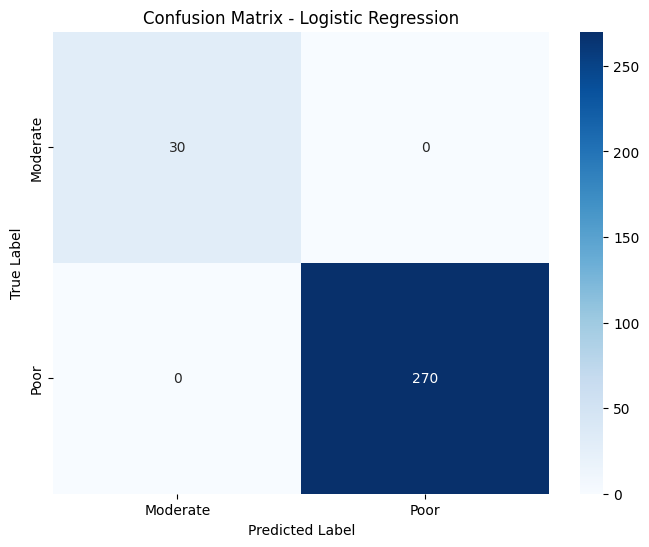

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=seed)
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_lr = log_reg_model.predict(X_test_scaled)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted', zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')
error_lr = 1 - accuracy_lr

print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression Precision: {precision_lr:.4f}")
print(f"Logistic Regression F1 Score: {f1_lr:.4f}")
print(f"Logistic Regression Error: {error_lr:.4f}")

print("\nActual Values (first 10):", y_test.head(10).tolist())
print("Predicted Values (first 10):", y_pred_lr[:10].tolist())

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder_air_quality.classes_, yticklabels=encoder_air_quality.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Artificial Neural Network (ANN)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
ANN Accuracy: 1.0000
ANN Precision: 1.0000
ANN F1 Score: 1.0000
ANN Error: 0.0000

Actual Values (first 10): [0, 1, 1, 1, 1, 0, 1, 1, 1, 0]
Predicted Values (first 10): [0, 1, 1, 1, 1, 0, 1, 1, 1, 0]


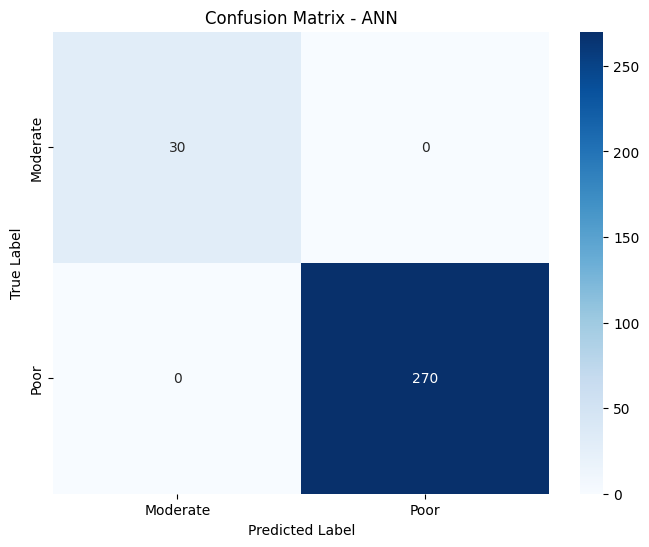

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Determine the number of output classes
num_classes = len(encoder_air_quality.classes_)

# Build the ANN model
ann_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax') # Softmax for multi-class classification
])

# Compile the model
ann_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = ann_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=0)

# Evaluate the model
loss_ann, accuracy_ann = ann_model.evaluate(X_test_scaled, y_test, verbose=0)

y_pred_ann_probs = ann_model.predict(X_test_scaled)
y_pred_ann = np.argmax(y_pred_ann_probs, axis=1)

precision_ann = precision_score(y_test, y_pred_ann, average='weighted', zero_division=0)
f1_ann = f1_score(y_test, y_pred_ann, average='weighted')
error_ann = 1 - accuracy_ann

print(f"ANN Accuracy: {accuracy_ann:.4f}")
print(f"ANN Precision: {precision_ann:.4f}")
print(f"ANN F1 Score: {f1_ann:.4f}")
print(f"ANN Error: {error_ann:.4f}")

print("\nActual Values (first 10):", y_test.head(10).tolist())
print("Predicted Values (first 10):", y_pred_ann[:10].tolist())

# Confusion Matrix
cm_ann = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder_air_quality.classes_, yticklabels=encoder_air_quality.classes_)
plt.title('Confusion Matrix - ANN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## ANN Training History: Accuracy Curve

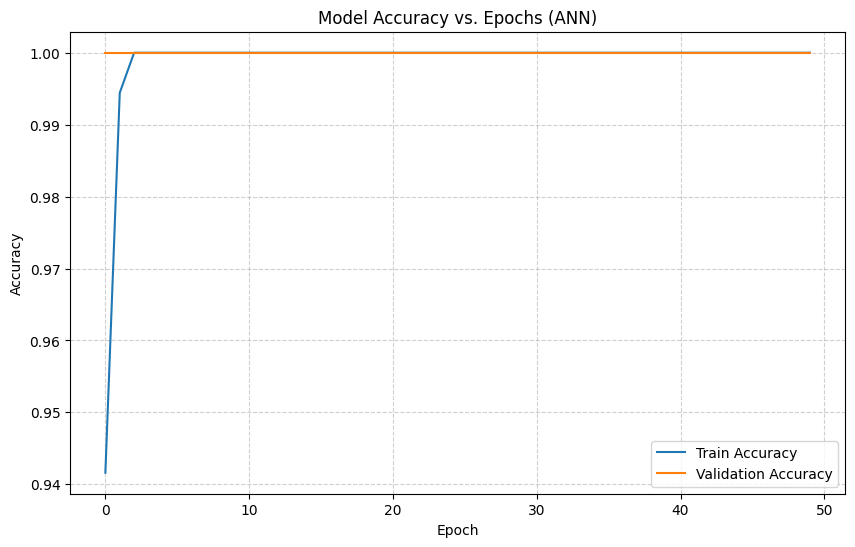

Observation: The plot shows the training and validation accuracy of the ANN model over 50 epochs. Both accuracies quickly reached 1.0, indicating rapid convergence and perfect classification on both seen and unseen data within a few epochs.


In [13]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy vs. Epochs (ANN)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Observation: The plot shows the training and validation accuracy of the ANN model over 50 epochs. Both accuracies quickly reached 1.0, indicating rapid convergence and perfect classification on both seen and unseen data within a few epochs.")

## ANN Training History: Loss Curve

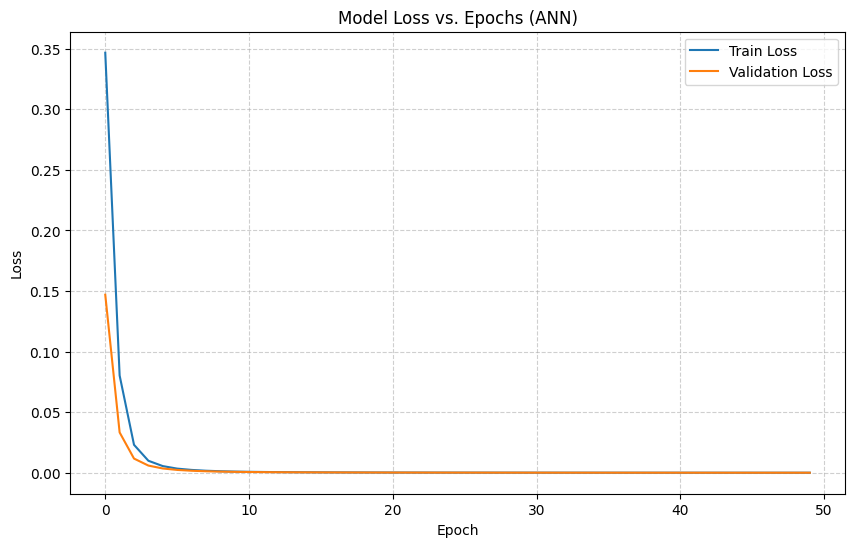

Observation: The plot shows the training and validation loss of the ANN model over 50 epochs. Both losses quickly converged to near zero, consistent with the high accuracy achieved by the model.


In [14]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss vs. Epochs (ANN)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("Observation: The plot shows the training and validation loss of the ANN model over 50 epochs. Both losses quickly converged to near zero, consistent with the high accuracy achieved by the model.")

### Random Forest Classifier

Random Forest Accuracy: 1.0000
Random Forest Precision: 1.0000
Random Forest F1 Score: 1.0000
Random Forest Error: 0.0000

Actual Values (first 10): [0, 1, 1, 1, 1, 0, 1, 1, 1, 0]
Predicted Values (first 10): [0, 1, 1, 1, 1, 0, 1, 1, 1, 0]


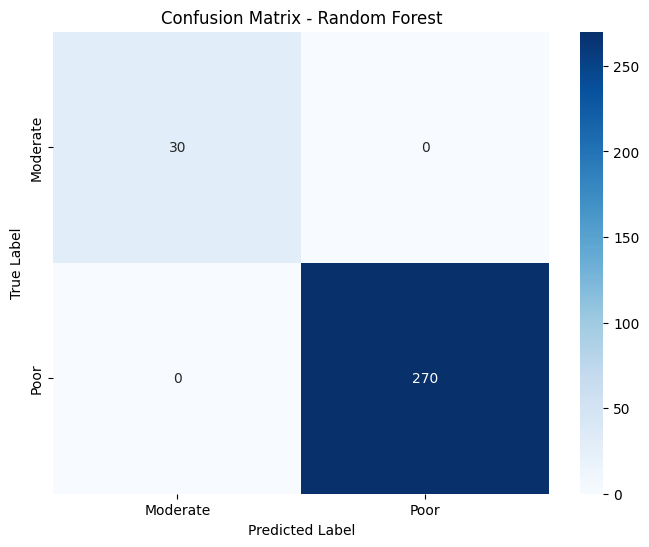

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(random_state=seed)
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
error_rf = 1 - accuracy_rf

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest F1 Score: {f1_rf:.4f}")
print(f"Random Forest Error: {error_rf:.4f}")

print("\nActual Values (first 10):", y_test.head(10).tolist())
print("Predicted Values (first 10):", y_pred_rf[:10].tolist())

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder_air_quality.classes_, yticklabels=encoder_air_quality.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### K-Nearest Neighbors (KNN) Classifier

KNN Accuracy: 1.0000
KNN Precision: 1.0000
KNN F1 Score: 1.0000
KNN Error: 0.0000

Actual Values (first 10): [0, 1, 1, 1, 1, 0, 1, 1, 1, 0]
Predicted Values (first 10): [0, 1, 1, 1, 1, 0, 1, 1, 1, 0]


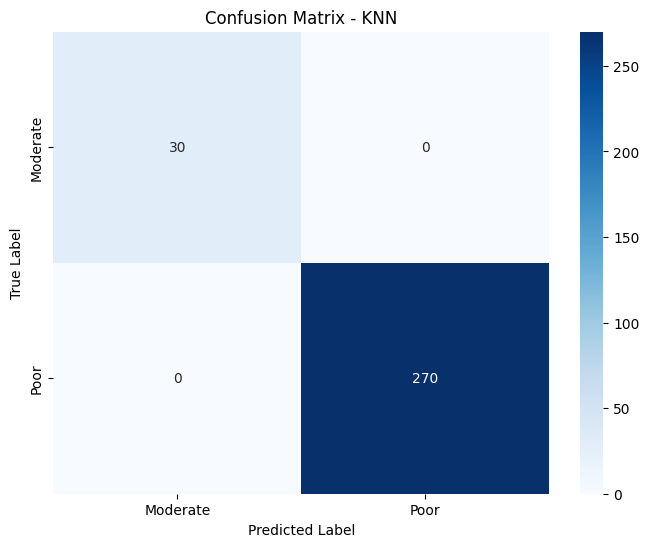

In [16]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the KNN model (using default n_neighbors=5, can be tuned)
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test_scaled)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')
error_knn = 1 - accuracy_knn

print(f"KNN Accuracy: {accuracy_knn:.4f}")
print(f"KNN Precision: {precision_knn:.4f}")
print(f"KNN F1 Score: {f1_knn:.4f}")
print(f"KNN Error: {error_knn:.4f}")

print("\nActual Values (first 10):", y_test.head(10).tolist())
print("Predicted Values (first 10):", y_pred_knn[:10].tolist())

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder_air_quality.classes_, yticklabels=encoder_air_quality.classes_)
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Model Comparison Summary

In [17]:
import pandas as pd

# Create a dictionary to store the results
results = {
    'Model': ['Logistic Regression', 'ANN', 'Random Forest', 'KNN'],
    'Accuracy': [accuracy_lr, accuracy_ann, accuracy_rf, accuracy_knn],
    'Precision': [precision_lr, precision_ann, precision_rf, precision_knn],
    'F1 Score': [f1_lr, f1_ann, f1_rf, f1_knn],
    'Error': [error_lr, error_ann, error_rf, error_knn]
}

# Create a DataFrame from the results
results_df = pd.DataFrame(results)

display(results_df)

print("\nObservation: All models (Logistic Regression, ANN, Random Forest, and KNN) achieved perfect scores (1.0 for Accuracy, Precision, F1 Score, and 0.0 for Error) on this dataset. This suggests that the 'Air quality' classes are highly separable based on the provided features. The scatter plot generated earlier also visually supported this perfect separability.")

,Model,Accuracy,Precision,F1 Score,Error
0,Logistic Regression,1.0,1.0,1.0,0.0
1,ANN,1.0,1.0,1.0,0.0
2,Random Forest,1.0,1.0,1.0,0.0
3,KNN,1.0,1.0,1.0,0.0



Observation: All models (Logistic Regression, ANN, Random Forest, and KNN) achieved perfect scores (1.0 for Accuracy, Precision, F1 Score, and 0.0 for Error) on this dataset. This suggests that the 'Air quality' classes are highly separable based on the provided features. The scatter plot generated earlier also visually supported this perfect separability.
